# Row 1: The live book tracks the next official GEX print

| field | content |
|---|---|
| frequency (GEX period) | every tick, compared with the next daily print |
| strength | 0.96 correlation of levels (a tracking measure, not a market outcome) |
| tradability (1 to 10) | 3 |
| holds for | all ten names. Sign agreement live versus stale print: SPY 93% versus 79%, QQQ 93% versus 82%, IWM 94% versus 87%, NVDA 99% versus 94%, TSLA 92% versus 81%, AAPL 99% versus 97%, AMZN 96% versus 94%, META 94% versus 86%, MSFT 97% versus 90%, AMD 93% versus 84% |
| how to trade | run the live book instead of waiting for the morning print; it feeds rows 2 to 5 |
| numbers (SPY) | sign agreement 92.9% live versus 79.5% stale; level correlation 0.96 versus 0.77; across 41 names 92.2% versus 85.3% |
| example | 2026-06-05: stale value +2.3 billion dollars, live value at the close -12.5 billion, official next print -6.2 billion, SPY -2.61% |
| video opener | The market makers who sell you options hedge them by buying and selling the stock, and the sum of that hedging, called gamma exposure or GEX, decides whether the market gets pushed around or held still. Most people look it up once a day from the morning open interest report. Take last night's positions and recompute the hedging at the price the stock trades right now and you already know tonight's number nine times out of ten, so you stop trading on yesterday's regime. |

In [1]:
import sys
import json
import warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")
sys.path.insert(0, "../gex_history")
import rows as R
import gexlib as G
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40)
ctx = R.load("spy")
print(ctx["sym"], len(ctx["daily"]), "days")

SPY 751 days


{
 "n_days": 750,
 "sign_agreement_stale": 0.7946666666666666,
 "sign_agreement_live": 0.9293333333333333,
 "corr_level_stale": 0.7719600283894616,
 "corr_level_live": 0.9631976315952924,
 "mad_stale_bn": 2.474937588,
 "mad_live_bn": 1.012439180853008,
 "days_sign_changed": 154,
 "live_caught_change": 0.7662337662337663
}


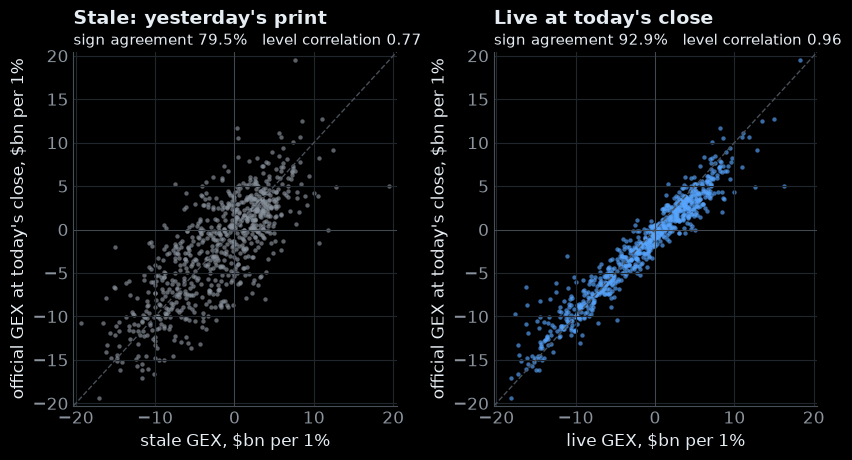

In [2]:
res = R.row1(ctx)
print(json.dumps(R.show(res), indent=1))
_ = R.fig1(ctx, res, G.FIGURES / 'row01_live_tracking.png')

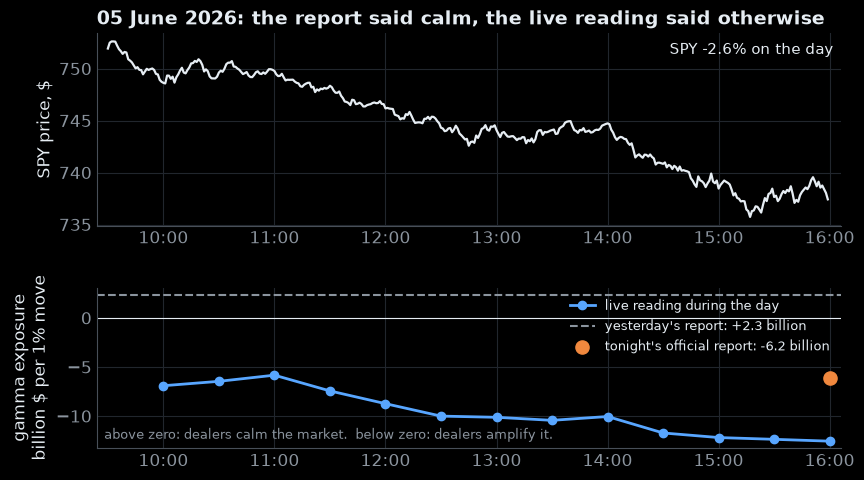

In [3]:
_ = R.fig_open1(ctx, res, G.FIGURES / 'row01_opener.png')   # the video opener, in dollars, percent and dates

In [4]:
R.per_name({'r1_sign_agree_live': 'sign agreement, live', 'r1_sign_agree_stale': 'sign agreement, stale print', 'r1_corr_live': 'level correlation, live', 'r1_corr_stale': 'level correlation, stale print'}).round(3)

,"sign agreement, live","sign agreement, stale print","level correlation, live","level correlation, stale print"
symbol,,,,
SPY,0.929,0.795,0.963,0.772
QQQ,0.928,0.820,0.968,0.773
IWM,0.940,0.868,0.957,0.822
NVDA,0.988,0.936,0.877,0.643
TSLA,0.920,0.808,0.895,0.703
AAPL,0.992,0.968,0.921,0.840
AMZN,0.960,0.944,0.940,0.797
META,0.944,0.864,0.916,0.729
MSFT,0.968,0.904,0.963,0.886
